### Diabetes data set

#### Import libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Data Gathering

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
X = df.drop(['Outcome'], axis = 1)
y = df['Outcome']

In [5]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                   test_size=0.20, random_state=42)

In [7]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [8]:
df['Outcome'].unique()

array([1, 0])

<Axes: xlabel='Outcome', ylabel='count'>

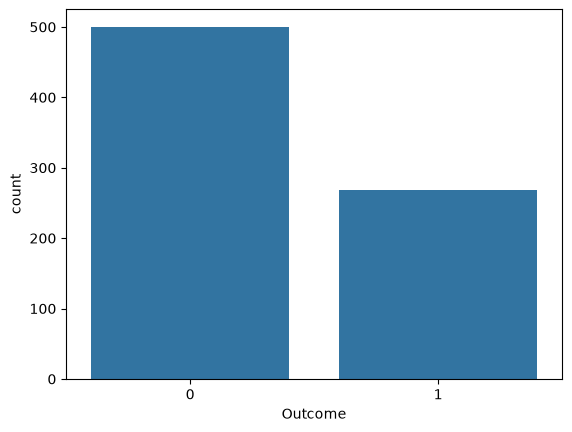

In [9]:
sns.countplot(x = df['Outcome'])

#### Build Decision Tree Model

In [10]:
dt_model = DecisionTreeClassifier(criterion='gini')
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Training data Accuarcy

In [11]:
y_pred_train = dt_model.predict(X_train)
y_pred_train[10:15]

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 1.0

Classification report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614


Confusion matrix is :
 [[401   0]
 [  0 213]]


### Testing data Accuarcy

In [12]:
y_pred_test = dt_model.predict(X_test)
y_pred_test[10:15]

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7467532467532467

Classification report :
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


Confusion matrix is :
 [[78 21]
 [18 37]]


In [13]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [14]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [15]:
y_test.value_counts()

Outcome
0    99
1    55
Name: count, dtype: int64

### Plot Decision Tree

In [16]:
plt.figure(figsize=(200,100))
tree = plot_tree(decision_tree = dt_model, feature_names=df.columns,class_names=['0','1'], filled = True)
plt.savefig('DT_Diabetes.png')

### Hyperparameter tuning

#### 1. GrisSearchCV

###### hyperparameters = {'criterion' : ['gini', 'entropy'],
                    'max_depth' : np.arange(2,10),
                    'min_samples_split' : np.arange(2,15),
                     'min_samples_leaf' : np.arange(2,16)}
dt_model = DecisionTreeClassifier()
dt_model
gscv_dt_model = GridSearchCV(dt_model, hyperparameters, cv=5)
gscv_dt_model.fit(X_train, y_train)

In [17]:
gscv_dt_model.best_params_

NameError: name 'gscv_dt_model' is not defined

In [18]:
best_dt_model = DecisionTreeClassifier(max_depth=7, min_samples_leaf=15
                                      , min_samples_split=2)
best_dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Training data accuracy GridSearchCV

In [19]:
y_pred_train = best_dt_model.predict(X_train)
y_pred_train[10:15]

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 0.8371335504885994

Classification report :
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       401
           1       0.74      0.81      0.78       213

    accuracy                           0.84       614
   macro avg       0.82      0.83      0.82       614
weighted avg       0.84      0.84      0.84       614


Confusion matrix is :
 [[341  60]
 [ 40 173]]


#### Testing data accuracy GridSearchCV

In [20]:
y_pred_test = best_dt_model.predict(X_test)
y_pred_test[10:15]

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7272727272727273

Classification report :
               precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154


Confusion matrix is :
 [[72 27]
 [15 40]]


In [21]:
# ============================================================
# SAVE TRAINED MODEL AS PICKLE FILE
# ============================================================

import pickle

# Save the trained Decision Tree model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(best_dt_model, file)

print(" Model saved successfully as diabetes_model.pkl")


# ============================================================
# SAVE FEATURE NAMES
# ============================================================

features = X.columns.tolist()

with open("diabetes_features.pkl", "wb") as file:
    pickle.dump(features, file)

print(" Features saved successfully as diabetes_features.pkl")

print("\nFeatures used by model:")
print(features)

 Model saved successfully as diabetes_model.pkl
 Features saved successfully as diabetes_features.pkl

Features used by model:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
